In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Exploration

In [2]:
births = Table.read_table('baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [3]:
births.select('Maternal Smoker', 'Birth Weight').show(5)

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136


In [4]:
means_table = (births.select('Maternal Smoker', 'Birth Weight')
               .group('Maternal Smoker', np.average)
              )
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


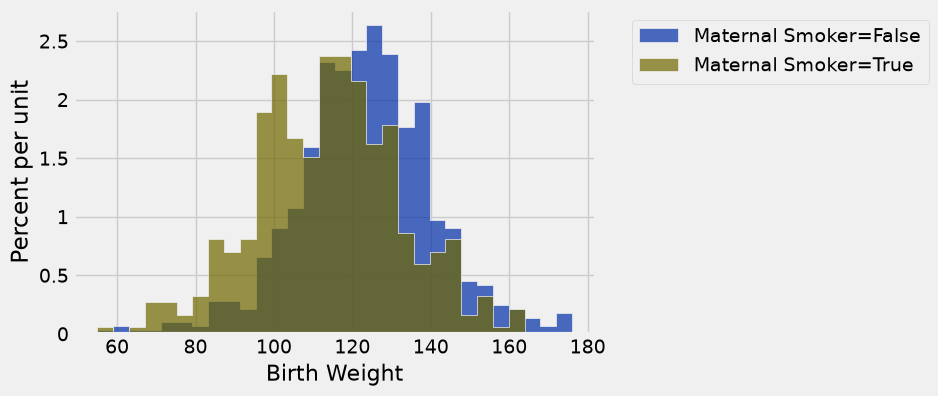

In [5]:
births.select('Maternal Smoker', 'Birth Weight').hist('Birth Weight', group='Maternal Smoker', bins = 30)

In [6]:
observed_difference = means_table.column(1).item(1) - means_table.column(1).item(0)
observed_difference

-9.266142572024918

## assume null hypothesis

In [7]:
births.select('Maternal Smoker').show(5)

Maternal Smoker
False
False
True
True
False


In [8]:
shuffled_grp=births.select('Maternal Smoker').sample(with_replacement=False)
shuffled_grp.show(5)

Maternal Smoker
True
True
False
False
False


In [9]:
simulated_births = Table().with_columns('Shuffled Maternal Smoker', shuffled_grp.column(0),
                                        'Birth Weight', births.column('Birth Weight'))
simulated_births.show(5)

Shuffled Maternal Smoker,Birth Weight
True,120
True,113
False,128
False,108
False,136


In [10]:
simulated_births.group('Shuffled Maternal Smoker', np.average)

Shuffled Maternal Smoker,Birth Weight average
False,119.255
True,119.786


In [11]:
means_array = simulated_births.group('Shuffled Maternal Smoker', np.average).column(1)
means_array

array([ 119.25454545,  119.78649237])

In [12]:
means_array.item(1) - means_array.item(0)

0.5319469201822216

In [13]:
def simulated_difference(table, group_label, numeric_label, function):
    """
    Arguments
        -name of table
        -col label of categorical variable
        -col label of numerical variable
        -statistic to be calculated
    Returns: difference in statistics of the two groups
    """
    shuffled_grp = table.select(group_label).sample(with_replacement=False)
    simulated_table = Table().with_columns(group_label, shuffled_grp.column(0),
                                           numeric_label, table.column(numeric_label))
    stats_array = simulated_table.group(group_label, function).column(1)
    return stats_array.item(1) - stats_array.item(0)

In [15]:
simulated_difference(births, 'Maternal Smoker', 'Birth Weight', np.average)

1.1508112802230528

In [ ]:
simulated_differences = make_array()
for i in np.arange(2500):
    simulated_differences = np.append(simulated_differences, simulated_difference(births, 'Maternal Smoker', 'Birth Weight', np.average))
simulated_differences

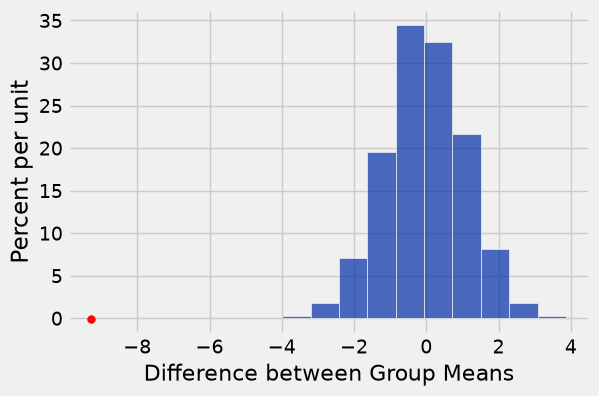

In [27]:
Table().with_columns('Difference between Group Means', simulated_differences).hist()
plt.scatter(observed_difference, -0.001, color='red', s=30)

# Causality

In [29]:
back_pain = Table.read_table('bta.csv')
back_pain.sample(5, with_replacement=False)

Group,Result
Control,0
Control,0
Control,0
Control,0
Treatment,0


In [30]:
back_pain.pivot('Result', 'Group')

Group,0.0,1.0
Control,14,2
Treatment,6,9


In [32]:
back_pain.group('Group', np.average)

Group,Result average
Control,0.125
Treatment,0.6


In [35]:
means_array = back_pain.group('Group', np.average).column('Result average')
means_array

array([ 0.125,  0.6  ])

In [37]:
observed_difference = abs(means_array.item(1) - means_array.item(0))
observed_difference

0.475

In [49]:
def simulated_abs_difference(table, group_label, numeric_label, function):
    """
    Arguments
        -name of table
        -col label of categorical variable
        -col label of numerical variable
        -statistic to be calculated
    Returns: difference in statistics of the two groups
    """
    shuffled_grp = table.select(group_label).sample(with_replacement=False)
    simulated_table = Table().with_columns(group_label, shuffled_grp.column(0),
                                           numeric_label, table.column(numeric_label))
    stats_array = simulated_table.group(group_label, function).column(1)
    return abs(stats_array.item(1) - stats_array.item(0))

In [50]:
simulated_abs_difference(back_pain, 'Group', 'Result', np.average)

0.041666666666666685

In [51]:
simulated_differences = make_array()
for i in np.arange(2500):
    simulated_differences = np.append(simulated_differences, simulated_abs_difference(back_pain, 'Group', 'Result', np.average))
simulated_differences

array([ 0.34583333,  0.04166667,  0.0875    , ...,  0.0875    ,
        0.0875    ,  0.42916667])

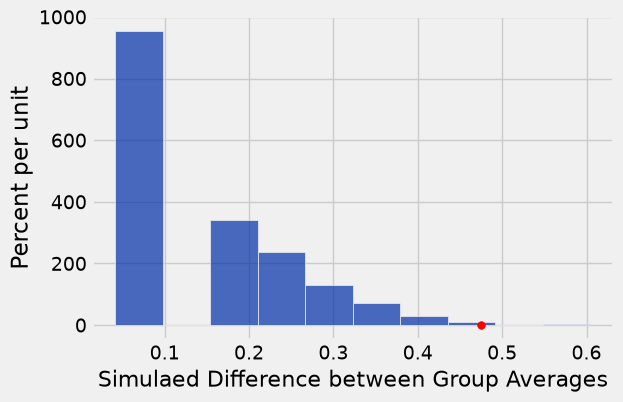

In [52]:
Table().with_column('Simulaed Difference between Group Averages', simulated_differences).hist()
plt.scatter(observed_difference, -0.001, color='red', s=30)

In [53]:
observed_difference

0.475

In [54]:
sum(simulated_differences >= observed_difference)/2500

0.0076